# Attack Model Evaluation

This notebook loads the best models for each attack (DDoS-ICMP, DDoS-SYN, Mirai-Greeth) and evaluates them, plotting confusion matrices, ROC curves, and feature importance.

In [1]:
import os
import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

ROOT_DIR = '../'
MODEL_DIR = os.path.join(ROOT_DIR, 'models', 'attack_specific')
DATA_DIR = os.path.join(ROOT_DIR, 'processed_ciciot23', 'attack_specific')

ATTACKS = ['ddos_icmp', 'ddos_syn', 'mirai_greeth']

## 1. Load Data and Best Models

In [2]:
models = {}
datasets = {}

for attack in ATTACKS:
    # Load best model name
    with open(os.path.join(MODEL_DIR, attack, 'best_name.txt'), 'r') as f:
        best_name = f.read().strip()
        
    # Load model
    with open(os.path.join(MODEL_DIR, attack, 'best.pkl'), 'rb') as f:
        model = pickle.load(f)
    models[attack] = model
    
    # Load data
    val_path = os.path.join(DATA_DIR, attack, 'validation.csv')
    val_df = pd.read_csv(val_path)
    
    with open(os.path.join(DATA_DIR, attack, 'metadata.json'), 'r') as f:
        meta = json.load(f)
    features = meta['features']
    
    X_val = val_df[features].values
    y_val = val_df['label_binary'].values
    
    datasets[attack] = {'X': X_val, 'y': y_val, 'features': features}
    print(f"{attack} -> Best Model: {best_name.upper()} | Val Data: {X_val.shape}")

ddos_icmp -> Best Model: RF | Val Data: (1176851, 22)


ddos_syn -> Best Model: RF | Val Data: (1176851, 23)


mirai_greeth -> Best Model: LGBM | Val Data: (1176851, 22)


## 2. ROC Curves

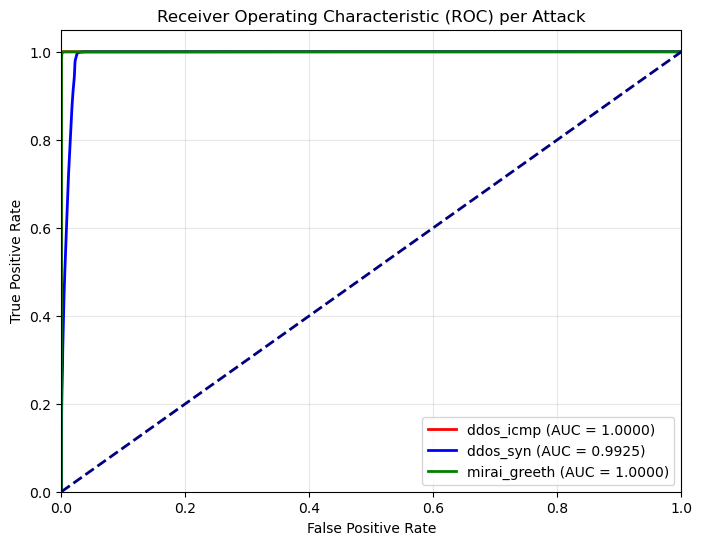

In [3]:
plt.figure(figsize=(8, 6))

colors = {'ddos_icmp': 'red', 'ddos_syn': 'blue', 'mirai_greeth': 'green'}

for attack in ATTACKS:
    model = models[attack]
    X_val = datasets[attack]['X']
    y_val = datasets[attack]['y']
    
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_val)[:, 1]
    else:
        y_score = model.decision_function(X_val)
        
    fpr, tpr, _ = roc_curve(y_val, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[attack], lw=2, label=f'{attack} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) per Attack')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 3. Cross-Attack Confusion Analysis
Test each model against the other attacks to see how specific the feature signatures truly are.

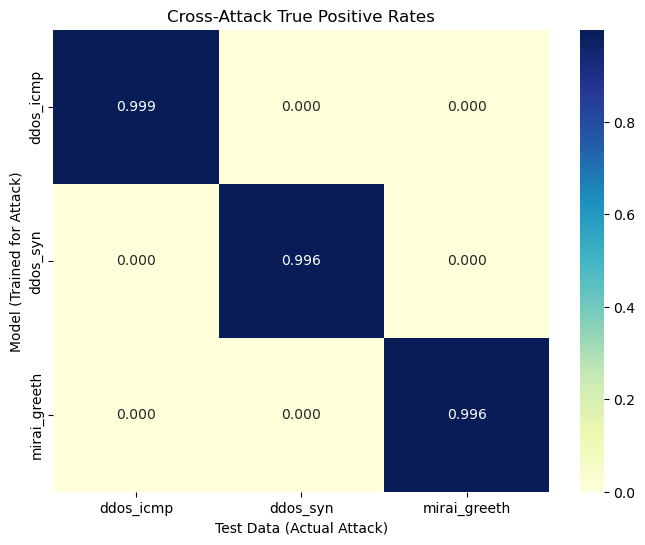

In [4]:
cross_results = np.zeros((len(ATTACKS), len(ATTACKS)))

for i, model_attack in enumerate(ATTACKS):
    model = models[model_attack]
    model_features = datasets[model_attack]['features']
    
    for j, data_attack in enumerate(ATTACKS):
        # Get the raw validation data of the target attack
        val_df = pd.read_csv(os.path.join(DATA_DIR, data_attack, 'validation.csv'))
        
        # Only test on the actual attack rows (label_binary == 1)
        attack_only = val_df[val_df['label_binary'] == 1]
        
        # Ensure the target dataframe has all features the model expects
        for f in model_features:
            if f not in attack_only.columns:
                attack_only[f] = 0.0
                
        X_test = attack_only[model_features].values
        y_true = np.ones(len(X_test)) # All are attacks
        
        if len(X_test) > 0:
            y_pred = model.predict(X_test)
            # TPR (Recall) on these attack samples
            tpr = np.mean(y_pred == 1)
        else:
            tpr = 0.0
            
        cross_results[i, j] = tpr

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cross_results, annot=True, cmap="YlGnBu", fmt=".3f", 
            xticklabels=ATTACKS, yticklabels=ATTACKS)
plt.xlabel('Test Data (Actual Attack)')
plt.ylabel('Model (Trained for Attack)')
plt.title('Cross-Attack True Positive Rates')
plt.show()